GAWA-T (FIXED — Global Negative Sampling InfoNCE)

Vocabulary size : 166 kata
Jumlah kalimat  : 101

Encoding dengan GAWA...
GAWA embeddings : torch.Size([166, 768])
Model parameters: 3,486,476

Training...
Epoch   0 | Loss: 0.5472 | InfoNCE: 0.5270 | Recon: 0.0629 | Locality: 0.0069
Epoch   1 | Loss: 1.2592 | InfoNCE: 1.2525 | Recon: 0.0203 | Locality: 0.0031
Epoch   2 | Loss: 2.0166 | InfoNCE: 2.0113 | Recon: 0.0157 | Locality: 0.0028
Epoch   3 | Loss: 2.7099 | InfoNCE: 2.7056 | Recon: 0.0120 | Locality: 0.0035
Epoch   4 | Loss: 3.3304 | InfoNCE: 3.3271 | Recon: 0.0091 | Locality: 0.0029
Epoch   5 | Loss: 3.1578 | InfoNCE: 3.1545 | Recon: 0.0089 | Locality: 0.0031
Epoch   6 | Loss: 4.4399 | InfoNCE: 4.4370 | Recon: 0.0074 | Locality: 0.0031
Epoch   7 | Loss: 3.6282 | InfoNCE: 3.6241 | Recon: 0.0104 | Locality: 0.0045
Epoch   8 | Loss: 4.7062 | InfoNCE: 4.7030 | Recon: 0.0070 | Locality: 0.0056
Epoch   9 | Loss: 4.5236 | InfoNCE: 4.5205 | Recon: 0.0062 | Locality: 0.0060
Epoch  10 | L

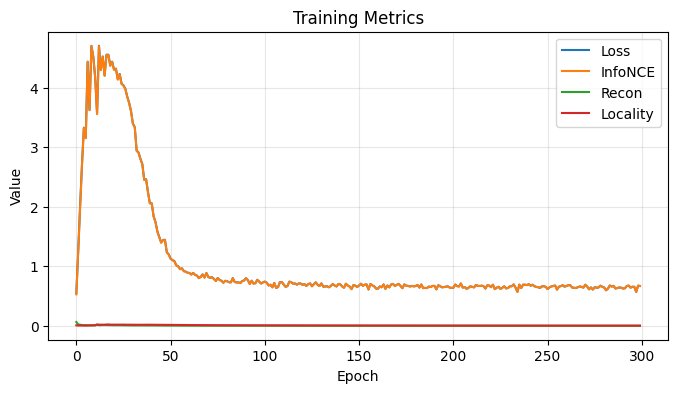


INFERENCE — Prediksi kata berikutnya

Context: saya sedang makan → ?
  Top 1: nasi            sim=0.7453
  Top 2: nelayan         sim=0.4445
  Top 3: menangis        sim=0.4445

Context: dia sedang minum → ?
  Top 1: air             sim=0.7804
  Top 2: hari            sim=0.5257
  Top 3: mainan          sim=0.4903

Context: anak itu berlari → ?
  Top 1: cepat           sim=0.7679
  Top 2: perawat         sim=0.4690
  Top 3: membaca         sim=0.4426

Context: saya mau minum → ?
  Top 1: air             sim=0.7840
  Top 2: hari            sim=0.5304
  Top 3: mainan          sim=0.4886

TEST OOV
Encoding OOV words via GAWA: ['makanan', 'meminum', 'berlarian']

Posisi OOV di semantic space:

  OOV: makanan
    → makan           sim=0.9445
    → pakaian         sim=0.9334
    → anak            sim=0.8806

  OOV: meminum
    → mie             sim=0.8194
    → minum           sim=0.7921
    → kucing          sim=0.7735

  OOV: berlarian
    → berlari         sim=0.9937
    → berjalan      

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from eval.encode import encode_words

# ── 1. GAWA ENCODER (frozen) ──────────────────────────────────────────
def get_gawa_vectors(words, checkpoint_path, device="cuda"):
    kept, embeddings = encode_words(
        checkpoint_path=checkpoint_path,
        words=words,
        batch_size=None,
        device=device,
    )
    return kept, torch.tensor(embeddings, dtype=torch.float32).to(device)


# ── 2. GEARBOX ────────────────────────────────────────────────────────
class Gearbox(nn.Module):
    def __init__(self, morph_dim=768, semantic_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(morph_dim, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Linear(512, semantic_dim),
            nn.GELU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(semantic_dim, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Linear(512, morph_dim),
        )

    def encode(self, v_morph):
        return self.encoder(v_morph)

    def decode(self, v_semantic):
        return self.decoder(v_semantic)

    def forward(self, v_morph):
        v_sem = self.encode(v_morph)
        v_rec = self.decode(v_sem)
        return v_sem, v_rec


# ── 3. POSITIONAL ENCODING (RoPE) ─────────────────────────────────────
class SimpleRoPE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)

    def forward(self, x):
        seq_len = x.shape[1]
        t = torch.arange(seq_len, device=x.device).float()
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat([freqs.sin(), freqs.cos()], dim=-1)
        return x + emb.unsqueeze(0)


# ── 4. ELASTIC GEOMETRIC ATTENTION ────────────────────────────────────
class ElasticGeometricAttention(nn.Module):
    def __init__(self, dim, n_heads=4):
        super().__init__()
        self.dim = dim
        self.n_heads = n_heads
        self.head_dim = dim // n_heads

        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)
        self.out = nn.Linear(dim, dim)

        self.lambda_geo = nn.Parameter(torch.ones(n_heads) * 0.5)

    def forward(self, x, gawa_vecs=None):
        B, S, D = x.shape
        H, HD = self.n_heads, self.head_dim

        Q = self.q(x).view(B, S, H, HD).transpose(1, 2)
        K = self.k(x).view(B, S, H, HD).transpose(1, 2)
        V = self.v(x).view(B, S, H, HD).transpose(1, 2)

        score = torch.matmul(Q, K.transpose(-2, -1)) / (HD ** 0.5)

        if gawa_vecs is not None:
            g = gawa_vecs
            dist = torch.cdist(g, g)
            lam = self.lambda_geo.view(1, H, 1, 1).abs()
            geo_penalty = torch.exp(-lam * dist.unsqueeze(1) ** 2)
            score = score * geo_penalty

        mask = torch.tril(torch.ones(S, S, device=x.device)).bool()
        score = score.masked_fill(~mask, float("-inf"))

        attn = F.softmax(score, dim=-1)
        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, S, D)
        return self.out(out)


# ── 5. TRANSFORMER BLOCK ──────────────────────────────────────────────
class GAWATransformerBlock(nn.Module):
    def __init__(self, dim, n_heads=4, ff_mult=4):
        super().__init__()
        self.norm1 = nn.RMSNorm(dim)
        self.norm2 = nn.RMSNorm(dim)
        self.attn = ElasticGeometricAttention(dim, n_heads)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim * ff_mult),
            nn.SiLU(),
            nn.Linear(dim * ff_mult, dim),
        )

    def forward(self, x, gawa_vecs=None):
        x = x + self.attn(self.norm1(x), gawa_vecs)
        x = x + self.ff(self.norm2(x))
        return x


# ── 6. REGRESSION HEAD ────────────────────────────────────────────────
class RegressionHead(nn.Module):
    def __init__(self, dim, semantic_dim=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.RMSNorm(dim),
            nn.Linear(dim, semantic_dim),
        )

    def forward(self, x):
        return self.proj(x[:, -1, :])


# ── 7. FULL GAWA-T MODEL ──────────────────────────────────────────────
class GAWATransformer(nn.Module):
    def __init__(self, morph_dim=768, semantic_dim=256, n_layers=3, n_heads=4):
        super().__init__()
        self.gearbox = Gearbox(morph_dim, semantic_dim)
        self.rope = SimpleRoPE(semantic_dim)
        self.layers = nn.ModuleList([
            GAWATransformerBlock(semantic_dim, n_heads)
            for _ in range(n_layers)
        ])
        self.head = RegressionHead(semantic_dim, semantic_dim)

    def forward(self, gawa_vecs):
        B, S, _ = gawa_vecs.shape
        v_flat = gawa_vecs.view(B * S, -1)
        v_sem, v_rec = self.gearbox(v_flat)
        v_sem = v_sem.view(B, S, -1)
        v_rec = v_rec.view(B, S, -1)
        x = self.rope(v_sem)
        for layer in self.layers:
            x = layer(x, gawa_vecs)
        pred_vec = self.head(x)
        return pred_vec, v_rec, v_sem


# ── 8. LOSS FUNCTION (DIPERBAIKI) ─────────────────────────────────────
class GAWALoss(nn.Module):
    """
    Perbaikan utama: infonce_loss sekarang menggunakan global negative sampling.
    Setiap langkah, model harus memilih target yang benar dari (target + n_neg
    kata acak dari seluruh vocab). Ini memaksa model belajar membedakan kata
    yang benar dari yang salah — bukan hanya mengecilkan loss trivial.
    """
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def infonce_loss(self, pred, target_sem, all_sem, n_neg=128):
        """
        pred       : (B, D)  — prediksi model
        target_sem : (B, D)  — vektor target yang benar
        all_sem    : (V, D)  — semua vektor vocab di semantic space (detached)
        n_neg      : jumlah negatif acak yang diambil dari vocab
        """
        B, D = pred.shape
        V    = all_sem.shape[0]

        pred_n   = F.normalize(pred,       dim=-1)   # (B, D)
        target_n = F.normalize(target_sem, dim=-1)   # (B, D)
        all_n    = F.normalize(all_sem,    dim=-1)   # (V, D)

        # Batasi n_neg agar tidak melebihi vocab size
        n_neg = min(n_neg, V - 1)

        loss_total = 0.0
        for i in range(B):
            # Ambil n_neg indeks acak — pastikan target tidak masuk negatif
            perm    = torch.randperm(V, device=pred.device)
            neg_idx = perm[:n_neg]
            negs    = all_n[neg_idx]                 # (n_neg, D)

            # Kandidat = [target] + [n_neg negatif]  →  (1 + n_neg, D)
            candidates = torch.cat([target_n[i].unsqueeze(0), negs], dim=0)

            # Logit: similarity pred vs semua kandidat
            logits = torch.matmul(
                pred_n[i].unsqueeze(0), candidates.T
            ) / self.temperature                     # (1, 1+n_neg)

            # Label = 0 karena target ada di posisi pertama
            label = torch.zeros(1, dtype=torch.long, device=pred.device)
            loss_total += F.cross_entropy(logits, label)

        return loss_total / B

    def reconstruction_loss(self, v_rec, v_morph_original):
        return F.mse_loss(v_rec, v_morph_original)

    def locality_loss(self, v_sem, v_morph):
        dist_morph = torch.cdist(v_morph, v_morph)
        dist_sem   = torch.cdist(v_sem,   v_sem)
        dist_morph = dist_morph / (dist_morph.max() + 1e-8)
        dist_sem   = dist_sem   / (dist_sem.max()   + 1e-8)
        return F.mse_loss(dist_sem, dist_morph)

    def forward(self, pred, target_sem, v_rec, v_morph, v_sem,
                all_sem=None, alpha=0.3, beta=0.2):
        if all_sem is None:
            raise ValueError(
                "all_sem wajib diisi! Berikan semua vektor vocab di semantic space."
            )
        l_infonce = self.infonce_loss(pred, target_sem, all_sem)
        l_recon   = self.reconstruction_loss(
                        v_rec.view(-1, v_morph.shape[-1]),
                        v_morph.view(-1, v_morph.shape[-1]))
        l_local   = self.locality_loss(
                        v_sem.view(-1, v_sem.shape[-1]),
                        v_morph.view(-1, v_morph.shape[-1]))
        total = l_infonce + alpha * l_recon + beta * l_local
        return total, {
            "infonce":        l_infonce.item(),
            "reconstruction": l_recon.item(),
            "locality":       l_local.item(),
        }


# ── 9. TRAINING LOOP ──────────────────────────────────────────────────
def run_toy_example(checkpoint_path, device="cuda"):
    print("=" * 60)
    print("GAWA-T (FIXED — Global Negative Sampling InfoNCE)")
    print("=" * 60)

    sentences = [
        (['saya', 'sedang', 'makan'], "nasi"),
        (['dia', 'sedang', 'minum'], "air"),
        (['anak', 'itu', 'berlari'], "cepat"),
        (['saya', 'suka', 'makan'], "nasi"),
        (['mereka', 'sedang', 'bermain'], "bola"),
        (['ibu', 'sedang', 'memasak'], "nasi"),
        (['adik', 'suka', 'berlari'], "pagi"),
        (['saya', 'mau', 'minum'], "air"),
        (['ayah', 'sedang', 'membaca'], "buku"),
        (['kakak', 'sedang', 'menulis'], "surat"),
        (['kami', 'sedang', 'belajar'], "matematika"),
        (['mereka', 'sedang', 'belajar'], "bahasa"),
        (['dia', 'suka', 'menyanyi'], "lagu"),
        (['anak', 'kecil', 'menangis'], "pelan"),
        (['guru', 'sedang', 'mengajar'], "kelas"),
        (['siswa', 'sedang', 'mengerjakan'], "tugas"),
        (['petani', 'sedang', 'menanam'], "padi"),
        (['nelayan', 'sedang', 'menangkap'], "ikan"),
        (['dokter', 'sedang', 'memeriksa'], "pasien"),
        (['perawat', 'sedang', 'merawat'], "pasien"),
        (['kami', 'suka', 'berjalan'], "pagi"),
        (['dia', 'suka', 'bersepeda'], "sore"),
        (['mereka', 'sedang', 'menonton'], "film"),
        (['saya', 'sedang', 'mencuci'], "piring"),
        (['ibu', 'sedang', 'mencuci'], "pakaian"),
        (['ayah', 'sedang', 'memperbaiki'], "motor"),
        (['adik', 'sedang', 'menggambar'], "rumah"),
        (['kakak', 'sedang', 'melukis'], "pemandangan"),
        (['kami', 'sedang', 'memasak'], "sup"),
        (['saya', 'sedang', 'memasak'], "mie"),
        (['dia', 'sedang', 'menyapu'], "lantai"),
        (['ibu', 'sedang', 'mengepel'], "lantai"),
        (['anak', 'itu', 'membawa'], "tas"),
        (['saya', 'membawa', 'payung'], "hari"),
        (['mereka', 'sedang', 'menanam'], "bunga"),
        (['kami', 'sedang', 'memetik'], "buah"),
        (['dia', 'sedang', 'memotong'], "kayu"),
        (['ayah', 'sedang', 'membangun'], "pagar"),
        (['ibu', 'sedang', 'menjahit'], "baju"),
        (['saya', 'sedang', 'menjahit'], "celana"),
        (['kakak', 'sedang', 'menyiram'], "tanaman"),
        (['adik', 'sedang', 'menyiram'], "bunga"),
        (['saya', 'sedang', 'membaca'], "koran"),
        (['dia', 'sedang', 'membaca'], "komik"),
        (['kami', 'sedang', 'bermain'], "catur"),
        (['mereka', 'sedang', 'bermain'], "bola"),
        (['anak', 'itu', 'bermain'], "layang"),
        (['saya', 'sedang', 'berlatih'], "lari"),
        (['dia', 'sedang', 'berlatih'], "renang"),
        (['kami', 'sedang', 'berenang'], "kolam"),
        (['mereka', 'sedang', 'berkemah'], "gunung"),
        (['saya', 'sedang', 'berkebun'], "rumah"),
        (['ibu', 'sedang', 'berbelanja'], "pasar"),
        (['ayah', 'sedang', 'bekerja'], "kantor"),
        (['kakak', 'sedang', 'bekerja'], "toko"),
        (['adik', 'sedang', 'belajar'], "menulis"),
        (['saya', 'sedang', 'belajar'], "membaca"),
        (['dia', 'sedang', 'menghafal'], "doa"),
        (['kami', 'sedang', 'mengingat'], "pelajaran"),
        (['mereka', 'sedang', 'mengulang'], "materi"),
        (['guru', 'sedang', 'menjelaskan'], "materi"),
        (['siswa', 'sedang', 'bertanya'], "guru"),
        (['anak', 'itu', 'menjawab'], "pertanyaan"),
        (['saya', 'sedang', 'menulis'], "catatan"),
        (['dia', 'sedang', 'menulis'], "cerita"),
        (['kami', 'sedang', 'membuat'], "kue"),
        (['ibu', 'sedang', 'membuat'], "teh"),
        (['ayah', 'sedang', 'membuat'], "meja"),
        (['kakak', 'sedang', 'membuat'], "poster"),
        (['adik', 'sedang', 'membuat'], "kolase"),
        (['saya', 'sedang', 'mengirim'], "pesan"),
        (['dia', 'sedang', 'menerima'], "telepon"),
        (['kami', 'sedang', 'menunggu'], "bus"),
        (['mereka', 'sedang', 'menunggu'], "kereta"),
        (['saya', 'sedang', 'mencari'], "kunci"),
        (['dia', 'sedang', 'mencari'], "sepatu"),
        (['ibu', 'sedang', 'menata'], "meja"),
        (['ayah', 'sedang', 'menata'], "kebun"),
        (['kakak', 'sedang', 'menata'], "rak"),
        (['adik', 'sedang', 'menata'], "mainan"),
        (['saya', 'sedang', 'membersihkan'], "kamar"),
        (['dia', 'sedang', 'membersihkan'], "halaman"),
        (['kami', 'sedang', 'memperbaiki'], "atap"),
        (['mereka', 'sedang', 'memperbaiki'], "jalan"),
        (['petugas', 'sedang', 'memeriksa'], "tiket"),
        (['penjaga', 'sedang', 'mengawasi'], "pintu"),
        (['penjaga', 'sedang', 'mengunci'], "gudang"),
        (['saya', 'sedang', 'mengantar'], "adik"),
        (['dia', 'sedang', 'mengantar'], "ibu"),
        (['kami', 'sedang', 'mengantar'], "teman"),
        (['mereka', 'sedang', 'mengantar'], "tamu"),
        (['saya', 'sedang', 'membuka'], "jendela"),
        (['dia', 'sedang', 'menutup'], "pintu"),
        (['anak', 'itu', 'melihat'], "kucing"),
        (['anak', 'itu', 'mengikuti'], "burung"),
        (['saya', 'sedang', 'menyimpan'], "uang"),
        (['dia', 'sedang', 'menyimpan'], "buku"),
        (['kami', 'sedang', 'menyusun'], "jadwal"),
        (['mereka', 'sedang', 'menyusun'], "rencana"),
        (['saya', 'sedang', 'mengukur'], "panjang"),
        (['dia', 'sedang', 'mengukur'], "jarak"),
    ]

    all_words = list(set(
        w for ctx, tgt in sentences for w in ctx + [tgt]
    ))

    print(f"\nVocabulary size : {len(all_words)} kata")
    print(f"Jumlah kalimat  : {len(sentences)}")

    print("\nEncoding dengan GAWA...")
    kept, all_embeddings = get_gawa_vectors(all_words, checkpoint_path, device)
    word2idx       = {w: i for i, w in enumerate(kept)}
    all_embeddings = all_embeddings.detach()

    print(f"GAWA embeddings : {all_embeddings.shape}")

    model = GAWATransformer(
        morph_dim=768,
        semantic_dim=256,
        n_layers=3,
        n_heads=4,
    ).to(device)

    criterion = GAWALoss(temperature=0.07)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {total_params:,}")

    print("\nTraining...")
    model.train()

    for epoch in range(300):
        total_loss   = 0.0
        loss_details = {"infonce": 0.0, "recon": 0.0, "locality": 0.0}

        # history untuk grafik
        if epoch == 0:
            loss_history = []
            infonce_history = []
            recon_history = []
            locality_history = []

        # Hitung all_sem fresh tiap epoch — gearbox ikut dilatih
        # detach() penting: tidak ingin gradien mengalir lewat negatif
        with torch.no_grad():
            all_sem_live, _ = model.gearbox(all_embeddings)  # (V, 256)

        for ctx_words, tgt_word in sentences:
            if any(w not in word2idx for w in ctx_words + [tgt_word]):
                continue

            ctx_idx  = [word2idx[w] for w in ctx_words]
            ctx_vecs = all_embeddings[ctx_idx].unsqueeze(0)   # (1, S, 768)
            tgt_idx  = word2idx[tgt_word]
            tgt_vec  = all_embeddings[tgt_idx].unsqueeze(0)   # (1, 768)

            pred_vec, v_rec, v_sem = model(ctx_vecs)

            with torch.no_grad():
                tgt_sem, _ = model.gearbox(tgt_vec)

            loss, details = criterion(
                pred_vec, tgt_sem, v_rec, ctx_vecs, v_sem,
                all_sem=all_sem_live,   # ← KUNCI PERBAIKAN
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            for k in loss_details:
                if k in details:
                    loss_details[k] += details[k]
                elif k == "recon" and "reconstruction" in details:
                    loss_details[k] += details["reconstruction"]

        scheduler.step()

        # Tampilkan metrik tiap epoch, dan pastikan epoch ke-4 muncul dalam format ringkas
        n = len(sentences)
        loss_line = (f"| Loss: {total_loss/n:.4f} | "
                     f"InfoNCE: {loss_details['infonce']/n:.4f} | "
                     f"Recon: {loss_details['recon']/n:.4f} | "
                     f"Locality: {loss_details['locality']/n:.4f}")
        print(f"Epoch {epoch:3d} {loss_line}")
        loss_history.append(total_loss/n)
        infonce_history.append(loss_details['infonce']/n)
        recon_history.append(loss_details['recon']/n)
        locality_history.append(loss_details['locality']/n)


    # Grafik loss
    try:
        import matplotlib.pyplot as plt
        epochs = list(range(len(loss_history)))
        plt.figure(figsize=(8,4))
        plt.plot(epochs, loss_history, label='Loss')
        plt.plot(epochs, infonce_history, label='InfoNCE')
        plt.plot(epochs, recon_history, label='Recon')
        plt.plot(epochs, locality_history, label='Locality')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.title('Training Metrics')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    except Exception as e:
        print(f"(Grafik tidak ditampilkan) {e}")

    # ── 10. INFERENCE ─────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("INFERENCE — Prediksi kata berikutnya")
    print("=" * 60)

    model.eval()

    with torch.no_grad():
        all_sem, _ = model.gearbox(all_embeddings)
        all_sem_np = F.normalize(all_sem, dim=-1).cpu().numpy()

    def predict_next(context_words, top_k=3):
        if any(w not in word2idx for w in context_words):
            print(f"  Ada kata OOV di context!")
            return
        ctx_idx  = [word2idx[w] for w in context_words]
        ctx_vecs = all_embeddings[ctx_idx].unsqueeze(0)
        with torch.no_grad():
            pred_vec, _, _ = model(ctx_vecs)
            pred_norm = F.normalize(pred_vec, dim=-1).cpu().numpy()
        sims    = np.dot(all_sem_np, pred_norm.T).flatten()
        top_idx = sims.argsort()[::-1][:top_k]
        print(f"\nContext: {' '.join(context_words)} → ?")
        for i, idx in enumerate(top_idx):
            print(f"  Top {i+1}: {kept[idx]:<15} sim={sims[idx]:.4f}")

    predict_next(["saya", "sedang", "makan"])
    predict_next(["dia", "sedang", "minum"])
    predict_next(["anak", "itu", "berlari"])
    predict_next(["saya", "mau", "minum"])

    print("\n" + "=" * 60)
    print("TEST OOV")
    print("=" * 60)

    oov_words = ["makanan", "meminum", "berlarian"]
    print(f"Encoding OOV words via GAWA: {oov_words}")
    oov_kept, oov_vecs = get_gawa_vectors(oov_words, checkpoint_path, device)
    oov_vecs = oov_vecs.detach()

    with torch.no_grad():
        oov_sem, _ = model.gearbox(oov_vecs)
        oov_sem_norm = F.normalize(oov_sem, dim=-1).cpu().numpy()

    print("\nPosisi OOV di semantic space:")
    for i, word in enumerate(oov_kept):
        sims    = np.dot(all_sem_np, oov_sem_norm[i])
        top_idx = sims.argsort()[::-1][:3]
        print(f"\n  OOV: {word}")
        for idx in top_idx:
            print(f"    → {kept[idx]:<15} sim={sims[idx]:.4f}")

    print("\nDone!")
    return model


# ── JALANKAN ──────────────────────────────────────────────────────────
if __name__ == "__main__":
    checkpoint_path = "checkpoints/best.pt"
    model = run_toy_example(checkpoint_path, device="cuda")


In [ ]:
# --- Setup minimal agar analogi jalan ---
import torch
import torch.nn.functional as F
from eval.encode import encode_words

checkpoint_path = "checkpoints/best.pt"
device = "cuda" if torch.cuda.is_available() else "cpu"


def gawa(word: str) -> torch.Tensor:
    kept, embs = encode_words(
        checkpoint_path=checkpoint_path,
        words=[word],
        batch_size=1,
        device=device,
    )
    if not kept:
        raise ValueError(f"Kata '{word}' terfilter (panjang kata tidak valid).")
    return torch.tensor(embs[0], dtype=torch.float32, device=device)


# Jika gearbox belum ada (misal cell training belum dijalankan), pakai identity
if "gearbox" not in globals():
    class _IdentityGearbox(torch.nn.Module):
        def encode(self, v_morph):
            return v_morph

    gearbox = _IdentityGearbox().to(device)


_nn_cache = {}


def nearest_neighbor(query_vec: torch.Tensor, candidate_words=None, top_k: int = 5):
    if candidate_words is None:
        candidate_words = [
            "pemakan",
            "makan",
            "minum",
            "peminum",
            "minuman",
            "makanan",
        ]
    key = tuple(candidate_words)
    if key not in _nn_cache:
        kept, embs = encode_words(
            checkpoint_path=checkpoint_path,
            words=list(candidate_words),
            batch_size=256,
            device=device,
        )
        vecs = torch.tensor(embs, dtype=torch.float32, device=device)
        vecs = gearbox.encode(vecs)
        vecs = F.normalize(vecs, dim=-1)
        _nn_cache[key] = (kept, vecs)

    kept, vecs = _nn_cache[key]
    q = query_vec
    if q.ndim == 2 and q.shape[0] == 1:
        q = q[0]
    q = F.normalize(q, dim=-1)

    sims = torch.matmul(vecs, q)
    top = torch.topk(sims, k=min(top_k, sims.numel()))
    for score, idx in zip(top.values.tolist(), top.indices.tolist()):
        print(f"{kept[idx]:<12} sim={score:.4f}")
    return kept[top.indices[0]]


# --- Analogi ---
vec_pemakan = gearbox.encode(gawa("pemakan"))
vec_makan = gearbox.encode(gawa("makan"))
vec_minum = gearbox.encode(gawa("minum"))

# Interpolasi: pemakan - makan + minum = ?
vec_peminum_synth = vec_pemakan - vec_makan + vec_minum
nearest_neighbor(vec_peminum_synth)  # Harusnya: "peminum"


peminum      sim=0.8731
minum        sim=0.8025
minuman      sim=0.7512
pemakan      sim=0.2912
makan        sim=0.0276


'peminum'